# Notebook 07 — Sentiment Comparison & Manual Evaluation

## What this notebook does

This is the decisive model-comparison notebook for Step 3. The previous two notebooks each produced a sentiment dataset independently — Notebook 05 generated `layer2_sentiment_baselines.parquet` with VADER, TF-IDF+LR, and calibrated TF-IDF+SVM; Notebook 06 generated `layer2_sentiment_finbert.parquet` with FinBERT full-text and headline-only tracks. Neither one can answer the thesis question on its own: *which sentiment model should we actually trust on TSLA?*

Answering that question requires two things that neither 05 nor 06 could produce alone:

1. **A shared evaluation set with human-assigned labels.** All four models predicted on the full ~85K corpus, but without ground truth, we can only measure inter-model agreement — not correctness. I draw a stratified 200-row sample here, label it manually, and measure accuracy against those labels.
2. **Statistical honesty about the comparison.** Point estimates of macro-F1 are not enough for a jury defense. I report bootstrap 95% confidence intervals around each score and use McNemar's test to tell whether any observed gap between two models is actually significant or just sample noise.

## Three analyses, in order

1. **Inter-model agreement on the full corpus (~85K docs).** No ground truth needed — pairwise Cohen's kappa between all four models. Answers: *where do the models agree, and where do they fight each other?*
2. **Per-model performance on the manually labeled 200.** Macro-F1 with bootstrap CIs, confusion matrices, per-source breakdown, McNemar's tests. This is the headline result of Step 3.
3. **Headline vs full-text FinBERT on the labeled news subset.** Tests whether the truncation mitigation (headline track from Nb06) was worth the added complexity.

## Outputs produced

| Artifact | Path |
|---|---|
| Unified 4-model sentiment dataset | `/kaggle/working/data/layer2_sentiment.parquet` |
| Consolidated comparison results | `/kaggle/working/results/comparison_results.json` |
| Labeling template (exported for manual fill) | `/kaggle/working/data/labeling_template.csv` |
| Filled labels (imported from disk) | `/kaggle/input/.../labeling_filled.csv` |
| Figures (PNG) | `/kaggle/working/figures/` |

## Note on the labeling workflow

This notebook has a deliberate pause point at the end of Section 3. The first half runs straight through, exports `labeling_template.csv`, and stops. I then fill that CSV manually in a spreadsheet — offline, with model predictions hidden, to keep annotations unbiased. Once the filled file is re-uploaded to Kaggle as a dataset, Sections 4 onward pick up and run to completion. The notebook is designed to be safely re-run end-to-end once labels exist.


## Section 0 — Setup

Same reproducibility anchors as in 05 and 06: fixed seed, explicit paths, logged versions. I keep the label schema identical (`[negative, neutral, positive]` in this order) because all four model outputs already use it — any deviation here would silently break joins.


In [1]:
# 0.1 — Install any missing dependencies, then import everything

import subprocess, sys, importlib

def _ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

for pkg, imp in [("statsmodels", "statsmodels"), ("seaborn", "seaborn")]:
    _ensure(pkg, imp)

import os, random, json, warnings
from pathlib import Path
from datetime import datetime
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    cohen_kappa_score, confusion_matrix,
)
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Imports ok")


Imports ok


In [2]:
# 0.2 — Configuration: seed, paths, label schema, plot style, version logging

SEED = 42
random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"] = str(SEED)

# Inputs — adjust Kaggle dataset slugs if different in your workspace.
# Both parquets come from the previous two notebooks (uploaded as Kaggle datasets).
BASELINES_PATH = "/kaggle/input/datasets/leev75/layer2-multimodel/layer2_sentiment_baselines.parquet"
FINBERT_PATH = "/kaggle/input/datasets/leev75/layer2-multimodel/layer2_sentiment_finbert.parquet"
# Filled labels — expected to exist only AFTER the manual labeling pause.
# Point this at the Kaggle dataset slug where you re-upload the filled CSV.
LABELS_FILLED_PATH = "/kaggle/input/datasets/leev75/labels-annotator-a-dhiaeddine-khelil/labels_annotator_A__Dhiaeddine_khelil.csv"

# Outputs
WORK_DIR    = Path("/kaggle/working")
DATA_DIR    = WORK_DIR / "data"
RESULTS_DIR = WORK_DIR / "results"
FIGURES_DIR = WORK_DIR / "figures"
for d in [DATA_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Label schema — must match the string literals used by all four models
LABELS = ["negative", "neutral", "positive"]

# The four models under evaluation. Naming follows the upstream column prefixes
# exactly — do not rename, the downstream Step 4 reads these.
MODELS = ["vader", "lr", "svm", "finbert"]
MODEL_DISPLAY = {"vader": "VADER", "lr": "TF-IDF + LR", "svm": "TF-IDF + SVM", "finbert": "FinBERT"}
LABEL_COLS = {m: f"{m}_label" for m in MODELS}

# Sources — order fixed for consistent figure axes
SOURCES = ["news", "reddit", "twitter_general", "twitter_musk"]

# Plot style — carried over from 05/06 so every thesis figure has the same look
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]   = 100
plt.rcParams["savefig.dpi"]  = 200
plt.rcParams["savefig.bbox"] = "tight"

VERSIONS = {
    "python":       sys.version.split()[0],
    "numpy":        np.__version__,
    "pandas":       pd.__version__,
    "sklearn":      __import__("sklearn").__version__,
    "statsmodels":  __import__("statsmodels").__version__,
}
RUN_TS = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")

print(f"Seed: {SEED}  |  Run: {RUN_TS}")
print(f"Baselines: {BASELINES_PATH}")
print(f"FinBERT:   {FINBERT_PATH}")
print(f"Labels:    {LABELS_FILLED_PATH}  (expected to exist only after manual labeling)")


Seed: 42  |  Run: 20260425T212741Z
Baselines: /kaggle/input/datasets/leev75/layer2-multimodel/layer2_sentiment_baselines.parquet
FinBERT:   /kaggle/input/datasets/leev75/layer2-multimodel/layer2_sentiment_finbert.parquet
Labels:    /kaggle/input/datasets/leev75/labels-annotator-a-dhiaeddine-khelil/labels_annotator_A__Dhiaeddine_khelil.csv  (expected to exist only after manual labeling)


/tmp/ipykernel_23/2450318268.py:47: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_TS = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


## Section 1 — Load and Merge the Two Prediction Files

The two upstream parquets overlap almost entirely in their non-prediction columns (`doc_id`, `published_at`, `source`, `text`, etc.) because both were built from the same `layer2_preprocessed.parquet`. The only thing that differs is the set of model-prediction columns each one carries.

I merge on `doc_id`, and I validate the join is strictly one-to-one. If it isn't, something went wrong upstream — most likely the same doc_id collision the Nb06 data-quality note flagged (two tweets with missing `tweet_id` sharing the placeholder URL, hashing to the same doc_id). The assertion will catch it.


In [3]:
# 1.1 — Load both prediction parquets

baselines = pd.read_parquet(BASELINES_PATH)
finbert   = pd.read_parquet(FINBERT_PATH)

print(f"Baselines: {baselines.shape}   cols: {len(baselines.columns)}")
print(f"FinBERT:   {finbert.shape}   cols: {len(finbert.columns)}")

# Identify the model-prediction columns in each file
baseline_pred_cols = [c for c in baselines.columns
                     if any(c.startswith(p) for p in ("vader_", "lr_", "svm_"))]
finbert_pred_cols  = [c for c in finbert.columns if c.startswith("finbert_")]

print(f"\nBaseline prediction columns ({len(baseline_pred_cols)}):")
print("  " + ", ".join(baseline_pred_cols))
print(f"\nFinBERT prediction columns ({len(finbert_pred_cols)}):")
print("  " + ", ".join(finbert_pred_cols))


Baselines: (85648, 25)   cols: 25
FinBERT:   (85649, 24)   cols: 24

Baseline prediction columns (13):
  vader_label, vader_compound, vader_pos, vader_neg, vader_neu, lr_label, lr_proba_neg, lr_proba_neu, lr_proba_pos, svm_label, svm_proba_neg, svm_proba_neu, svm_proba_pos

FinBERT prediction columns (12):
  finbert_label, finbert_p_neg, finbert_p_neu, finbert_p_pos, finbert_confidence, finbert_is_confident, finbert_label_headline, finbert_p_neg_headline, finbert_p_neu_headline, finbert_p_pos_headline, finbert_confidence_headline, finbert_is_confident_headline


In [4]:
baselines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85648 entries, 0 to 85647
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   doc_id           85648 non-null  object             
 1   published_at     85648 non-null  datetime64[ns, UTC]
 2   source           85648 non-null  object             
 3   text             85648 non-null  object             
 4   ticker           85648 non-null  object             
 5   url              84718 non-null  object             
 6   tokens_raw       85648 non-null  object             
 7   tokens_filtered  85648 non-null  object             
 8   tokens_lemma     85648 non-null  object             
 9   entities         85648 non-null  object             
 10  has_tsla_entity  85648 non-null  bool               
 11  n_tokens_lemma   85648 non-null  int64              
 12  vader_label      85648 non-null  object             
 13  vader_compound  

In [5]:
# 1.2 — Merge on doc_id (strict one-to-one)

# Keep the non-prediction columns from baselines as the canonical metadata,
# and only pull the finbert_* columns from the FinBERT parquet. This avoids
# duplicating `text`, `source`, `published_at` in the output.
n_dup_baselines = baselines.duplicated(subset=["doc_id"], keep=False).sum()
if n_dup_baselines > 0:
    baselines = baselines.drop_duplicates(subset=["doc_id"], keep="first").reset_index(drop=True)
    print(f"Removed {n_dup_baselines} duplicate doc_ids from baselines (kept first occurrence)")

n_dup_finbert = finbert.duplicated(subset=["doc_id"], keep=False).sum()
if n_dup_finbert > 0:
    finbert = finbert.drop_duplicates(subset=["doc_id"], keep="first").reset_index(drop=True)
    print(f"Removed {n_dup_finbert} duplicate doc_ids from finbert (kept first occurrence)")

# Now merge on the deduplicated tables
finbert_slice = finbert[["doc_id"] + finbert_pred_cols].copy()

assert baselines["doc_id"].is_unique,    "baselines still has duplicate doc_ids after dedup"
assert finbert_slice["doc_id"].is_unique, "finbert still has duplicate doc_ids after dedup"

merged = baselines.merge(finbert_slice, on="doc_id", how="inner", validate="one_to_one")

n_lost_left  = len(baselines)     - len(merged)
n_lost_right = len(finbert_slice) - len(merged)
print(f"Merged shape: {merged.shape}")
print(f"Dropped from baselines side (no FinBERT prediction): {n_lost_left}")
print(f"Dropped from FinBERT side (no baseline prediction):  {n_lost_right}")

assert n_lost_left < 50 and n_lost_right < 50, \
    "Unexpected merge loss — re-check upstream notebooks for silent row drops"


Removed 2 duplicate doc_ids from baselines (kept first occurrence)
Merged shape: (85647, 37)
Dropped from baselines side (no FinBERT prediction): 0
Dropped from FinBERT side (no baseline prediction):  2


In [6]:
# 1.3 — Sanity: every row has all four model predictions

for m in MODELS:
    col = LABEL_COLS[m]
    n_null = merged[col].isna().sum()
    assert n_null == 0, f"{col} has {n_null} nulls"
    # Verify label values are in the allowed set
    unique_labels = set(merged[col].unique())
    assert unique_labels.issubset(set(LABELS)), f"{col} has unexpected labels: {unique_labels - set(LABELS)}"
    print(f"{MODEL_DISPLAY[m]:<16} ok — {len(merged):,} predictions, labels in {sorted(unique_labels)}")


VADER            ok — 85,647 predictions, labels in ['negative', 'neutral', 'positive']
TF-IDF + LR      ok — 85,647 predictions, labels in ['negative', 'neutral', 'positive']
TF-IDF + SVM     ok — 85,647 predictions, labels in ['negative', 'neutral', 'positive']
FinBERT          ok — 85,647 predictions, labels in ['negative', 'neutral', 'positive']


## Section 2 — Inter-Model Agreement on the Full Corpus

Before touching manual labels, it's worth asking what the four models think about each other on the full 85K dataset. High agreement between two models on 85K documents is a strong signal that they behave similarly, regardless of which one is actually right. Low agreement is where the real information lives — those are the documents the models contest, and they're the ones manual labeling must cover.

I use Cohen's kappa rather than raw percent-agreement because two labels like "neutral, neutral" look like agreement but carry almost no information when 60–80% of predictions are neutral to begin with. Kappa corrects for the agreement you'd expect by chance given the class distribution, which matters a lot on this dataset.

Interpretation scale (Landis & Koch, 1977): `<0.20` slight, `0.21–0.40` fair, `0.41–0.60` moderate, `0.61–0.80` substantial, `>0.80` almost perfect.


In [7]:
# 2.1 — Pairwise Cohen's kappa between all four models, on the full corpus

kappa_matrix = pd.DataFrame(index=[MODEL_DISPLAY[m] for m in MODELS],
                            columns=[MODEL_DISPLAY[m] for m in MODELS], dtype=float)

for m1 in MODELS:
    for m2 in MODELS:
        if m1 == m2:
            kappa_matrix.loc[MODEL_DISPLAY[m1], MODEL_DISPLAY[m2]] = 1.0
        else:
            k = cohen_kappa_score(merged[LABEL_COLS[m1]], merged[LABEL_COLS[m2]], labels=LABELS)
            kappa_matrix.loc[MODEL_DISPLAY[m1], MODEL_DISPLAY[m2]] = k

print("Pairwise Cohen's kappa (full corpus, N = {:,}):\n".format(len(merged)))
print(kappa_matrix.round(3).to_string())


Pairwise Cohen's kappa (full corpus, N = 85,647):

              VADER  TF-IDF + LR  TF-IDF + SVM  FinBERT
VADER         1.000        0.234         0.206    0.166
TF-IDF + LR   0.234        1.000         0.872    0.323
TF-IDF + SVM  0.206        0.872         1.000    0.323
FinBERT       0.166        0.323         0.323    1.000


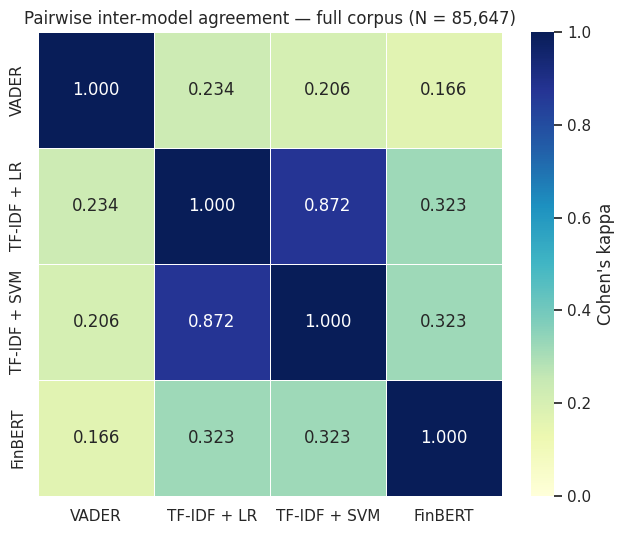

Saved: /kaggle/working/figures/07_kappa_heatmap.png


In [8]:
# 2.2 — Agreement heatmap

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(kappa_matrix.astype(float), annot=True, fmt=".3f",
            cmap="YlGnBu", vmin=0, vmax=1, cbar_kws={"label": "Cohen's kappa"},
            linewidths=0.5, ax=ax)
ax.set_title(f"Pairwise inter-model agreement — full corpus (N = {len(merged):,})")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()

out = FIGURES_DIR / "07_kappa_heatmap.png"
plt.savefig(out)
plt.show()
print(f"Saved: {out}")


Cohen's kappa per (model pair × source):

source                        news  reddit  twitter_general  twitter_musk
pair                                                                     
TF-IDF + LR vs FinBERT       0.386   0.180            0.255         0.276
TF-IDF + LR vs TF-IDF + SVM  0.899   0.855            0.839         0.794
TF-IDF + SVM vs FinBERT      0.380   0.197            0.258         0.267
VADER vs FinBERT             0.248   0.064            0.095         0.128
VADER vs TF-IDF + LR         0.401   0.124            0.078         0.124
VADER vs TF-IDF + SVM        0.370   0.108            0.060         0.084


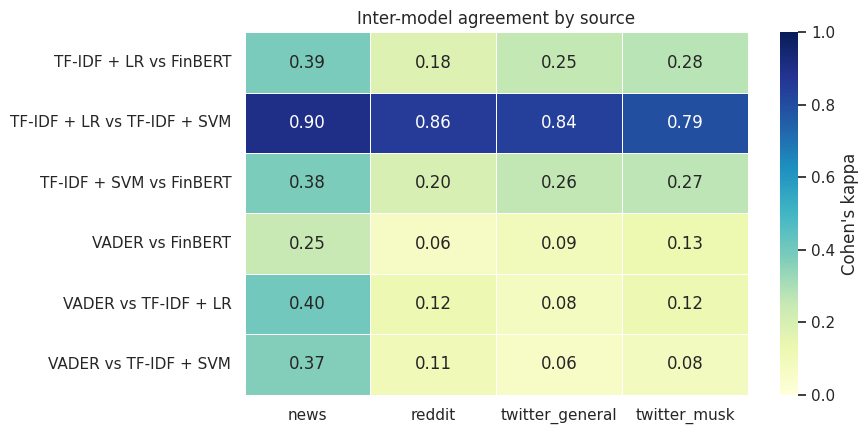

Saved: /kaggle/working/figures/07_kappa_by_source.png


In [9]:
# 2.3 — Where is disagreement concentrated? Per-source kappa pairs

# For the two supervised baselines and FinBERT, do the kappas hold across sources?
# If a pair of models agrees strongly on news but poorly on Twitter, that tells us
# something useful about the text register where each model is reliable.

pair_rows = []
for m1, m2 in combinations(MODELS, 2):
    for src in SOURCES:
        sub = merged[merged["source"] == src]
        if len(sub) < 30:
            k = np.nan
        else:
            k = cohen_kappa_score(sub[LABEL_COLS[m1]], sub[LABEL_COLS[m2]], labels=LABELS)
        pair_rows.append({
            "pair": f"{MODEL_DISPLAY[m1]} vs {MODEL_DISPLAY[m2]}",
            "source": src,
            "kappa": k,
            "n": len(sub),
        })

pair_df = pd.DataFrame(pair_rows)
pair_pivot = pair_df.pivot(index="pair", columns="source", values="kappa")[SOURCES]

print("Cohen's kappa per (model pair × source):\n")
print(pair_pivot.round(3).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pair_pivot.astype(float), annot=True, fmt=".2f", cmap="YlGnBu",
            vmin=0, vmax=1, cbar_kws={"label": "Cohen's kappa"}, linewidths=0.5, ax=ax)
ax.set_title("Inter-model agreement by source")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
out = FIGURES_DIR / "07_kappa_by_source.png"
plt.savefig(out); plt.show()
print(f"Saved: {out}")


## Section 3 — Drawing the Manual Labeling Sample

I draw a stratified 200-row sample: 50 documents per source, sampled with a fixed seed (42) from the `is_too_short == False` subset. The stratification is deliberate — news is the majority source (~42K out of 85K) and would dominate a proportional sample, which would hurt statistical power on the smaller-but-noisier Reddit and twitter_musk subsets where the FinBERT-vs-baseline gap is most interesting.

I considered three alternatives:

1. **Reusing the Nb02 diagnostic 200-row sample.** Tempting for continuity, but Nb02 was drawn specifically to surface problems, which biases it slightly against FinBERT in a clean-text evaluation.
2. **Prediction-conditional stratification** (ensuring each model × class cell has ≥N docs). This would bias the evaluation toward the models used for stratification.
3. **Fresh simple stratification by source only** (chosen). Clean, defensible, and 50 per source gives ~15 minimum class samples per source-label cell in expectation — enough for stable per-class F1.

### Anti-bias discipline during labeling

The exported template contains only `doc_id`, `source`, `text`, and an empty `label` column. Model predictions are deliberately excluded from the template — I fill the labels blind, then re-upload and join predictions back in Section 5. Pre-filling with a model's prediction would turn this into an "edit the model's guess" task instead of a true manual annotation, which destroys the evaluation's validity.


In [10]:
# 3.1 — Draw the stratified 200-row sample

SAMPLE_PER_SOURCE = 50
TOTAL_SAMPLE = SAMPLE_PER_SOURCE * len(SOURCES)

# Exclude is_too_short rows if the column exists (it's from Nb03/04)
if "is_too_short" in merged.columns:
    pool = merged[~merged["is_too_short"].fillna(False)].copy()
    print(f"Excluded {(merged['is_too_short'].fillna(False)).sum():,} too-short rows")
else:
    pool = merged.copy()
    print("No is_too_short column found — using all rows")

# Also exclude any empty texts as a safety net
pool = pool[pool["text"].str.strip().str.len() > 0].copy()

sample_parts = []
for src in SOURCES:
    src_pool = pool[pool["source"] == src]
    assert len(src_pool) >= SAMPLE_PER_SOURCE, f"Not enough {src} rows: {len(src_pool)}"
    s = src_pool.sample(n=SAMPLE_PER_SOURCE, random_state=SEED)
    sample_parts.append(s)

sample = pd.concat(sample_parts, ignore_index=True)
assert len(sample) == TOTAL_SAMPLE
assert sample["doc_id"].is_unique, "Sample has duplicate doc_ids"

print(f"\nSample drawn: {len(sample)} rows  ({SAMPLE_PER_SOURCE} per source × {len(SOURCES)} sources)")
print("\nSample per source:")
print(sample["source"].value_counts().reindex(SOURCES).to_string())


No is_too_short column found — using all rows

Sample drawn: 200 rows  (50 per source × 4 sources)

Sample per source:
source
news               50
reddit             50
twitter_general    50
twitter_musk       50


In [11]:
# 3.2 — Export labeling_template.csv (blind — no model predictions included)

template = sample[["doc_id", "source", "text"]].copy()

# Truncate displayed text length to keep the spreadsheet workable
# (full text stays in the parquet — this CSV is just for labeling)
template["text"] = template["text"].str.replace("\n", " ").str.replace("\r", " ")

template_path = DATA_DIR / "labeling_template.csv"
template.to_csv(template_path, index=False, encoding="utf-8")

print(f"Saved: {template_path}")
print(f"Rows:  {len(template)}")
print(f"\nColumn schema:")
for c in template.columns:
    print(f"  {c}")

# Also save the sample itself (with all columns including predictions) to disk.
# This is internal to the notebook — we need it later to join predictions back to labels.
sample_internal_path = DATA_DIR / "_internal_sample_with_preds.parquet"
sample.to_parquet(sample_internal_path, index=False)
print(f"\nInternal snapshot saved: {sample_internal_path}")


Saved: /kaggle/working/data/labeling_template.csv
Rows:  200

Column schema:
  doc_id
  source
  text

Internal snapshot saved: /kaggle/working/data/_internal_sample_with_preds.parquet


### ⏸ PAUSE — Manual labeling required before Section 4

At this point the notebook exports two files:

- `labeling_template.csv` — to be filled manually, **offline**, with a dedicated app interface.
- `_internal_sample_with_preds.parquet` — kept internal, joined back after labels return.

**How I fill the template:**

1. Download `labeling_template.csv` from the Kaggle notebook output panel.
2. Open in the dedicated app for assigning sentiment.
3. Re-upload the filled file to Kaggle as a dataset — same schema. Point `LABELS_FILLED_PATH` in Section 0.2 at it.
4. Restart the notebook and re-run from the top. Sections 0–3 are idempotent; Section 4 will now find the filled file and proceed.

## Section 4 — Load and Validate Manual Labels

Everything below this line assumes `labeling_filled.csv` exists and is reachable via `LABELS_FILLED_PATH`. If it doesn't, the notebook raises a clear error and stops — a deliberate choice.


In [12]:
labels_df = pd.read_csv(LABELS_FILLED_PATH, encoding="utf-8", keep_default_na=False)


In [13]:
# 4.1 — Load labels and run strict schema validation
# Required columns
required = {"doc_id", "label"}
missing = required - set(labels_df.columns)
assert not missing, f"Missing required columns: {missing}"

# Normalize label strings — strip whitespace, lowercase, catch common typos
labels_df["label"] = labels_df["label"].astype(str).str.strip().str.lower()

# Every label must be in the allowed set, no blanks
invalid_mask = ~labels_df["label"].isin(LABELS)
n_invalid = invalid_mask.sum()
if n_invalid > 0:
    bad_rows = labels_df.loc[invalid_mask, ["doc_id", "label"]].head(10)
    print("Invalid labels found (first 10):")
    print(bad_rows.to_string())
    raise ValueError(f"{n_invalid} rows have invalid labels (not in {LABELS}).")

# doc_ids must match the exported sample exactly
sample = pd.read_csv("/kaggle/input/datasets/leev75/lab1111/labeling_sample_reference.csv")
sample_ids = set(sample["doc_id"])
label_ids  = set(labels_df["doc_id"])

missing_in_labels = sample_ids - label_ids
extra_in_labels   = label_ids - sample_ids
assert not missing_in_labels, f"{len(missing_in_labels)} doc_ids in sample but not in labels"
assert not extra_in_labels,   f"{len(extra_in_labels)} extra doc_ids in labels — wrong file?"

print(f"Loaded: {len(labels_df)} labels, all valid")
print(f"All {len(sample)} sample doc_ids have corresponding labels ✓")


Loaded: 200 labels, all valid
All 200 sample doc_ids have corresponding labels ✓


In [14]:
# 4.2 — Join labels back to the sample (with predictions), produce the eval frame
# Keep only doc_id + label(s) + notes from the labels file, then merge.
cols_to_keep = ["doc_id", "label"]
if "label_alt" in labels_df.columns:
    cols_to_keep.append("label_alt")
if "notes" in labels_df.columns:
    cols_to_keep.append("notes")

eval_df = sample.merge(labels_df[cols_to_keep], on="doc_id", how="inner", validate="one_to_one")
assert len(eval_df) == len(sample), "Join lost rows — should not happen given earlier validation"

# Rename `label` to `y_true` for clarity in downstream code
eval_df = eval_df.rename(columns={"label": "y_true"})

# Class distribution sanity
print("Labeled class distribution (overall):")
print(eval_df["y_true"].value_counts().reindex(LABELS).to_string())

print("\nLabeled class distribution per source:")
print(eval_df.groupby("source")["y_true"].value_counts().unstack().reindex(SOURCES)[LABELS].fillna(0).astype(int).to_string())


Labeled class distribution (overall):
y_true
negative     27
neutral     101
positive     72

Labeled class distribution per source:
y_true           negative  neutral  positive
source                                      
news                    8       30        12
reddit                  8       26        16
twitter_general         7       12        31
twitter_musk            4       33        13


In [15]:
# 4.3 — Optional: inter-annotator Cohen's kappa (only if label_alt was filled)

if "label_alt" in eval_df.columns:
    alt_filled = eval_df["label_alt"].astype(str).str.strip().str.lower()
    n_alt_filled = alt_filled.isin(LABELS).sum()

    if n_alt_filled >= 50:
        # Enough second-annotator labels to compute kappa (need meaningful N)
        mask = alt_filled.isin(LABELS)
        kappa_inter = cohen_kappa_score(
            eval_df.loc[mask, "y_true"], alt_filled[mask], labels=LABELS,
        )
        pct_agreement = (eval_df.loc[mask, "y_true"] == alt_filled[mask]).mean()
        print(f"Inter-annotator agreement (N = {mask.sum()}):")
        print(f"  Raw percent agreement: {pct_agreement:.3f}")
        print(f"  Cohen's kappa:         {kappa_inter:.3f}")
        if kappa_inter >= 0.7:
            print("  → Substantial-to-strong agreement; labels defensible as ground truth.")
        elif kappa_inter >= 0.5:
            print("  → Moderate agreement; flag in thesis limitations.")
        else:
            print("  → Low agreement; reconsider annotation guidelines before reporting.")
    else:
        print(f"Only {n_alt_filled} second-annotator labels present — skipping kappa (need ≥50).")
        kappa_inter = None
else:
    print("No label_alt column — solo annotation. Inter-annotator kappa not reported.")
    kappa_inter = None


No label_alt column — solo annotation. Inter-annotator kappa not reported.


## Section 5 — Per-Model Performance on the Labeled Set

This is the headline result of the notebook. For each of the four models I compute accuracy, macro-F1, weighted-F1, and per-class precision/recall/F1 against the manual labels. Macro-F1 is the comparison metric I quote in the thesis — it weighs all three classes equally, which is the right choice when "neutral" dominates the prediction distribution and I care about whether the models can also recognize the minority positive and negative cases.

A single point estimate of macro-F1 isn't enough for a defense. I report a bootstrap 95% confidence interval around each score with 1000 resamples. If the CIs for FinBERT and, say, TF-IDF+LR overlap substantially, I don't get to claim FinBERT is better on this dataset — I report the draw honestly.


In [16]:
# 5.1 — Point-estimate metrics table
# IMPORTANT: eval_df must have the full model-prediction columns (vader_label, lr_label, svm_label, finbert_label).
# These are lost when we reload from the internal sample snapshot if Sections 3–4 were run in isolation.
# Solution: re-join eval_df with merged on doc_id to restore all prediction columns.

pred_cols_to_restore = [c for c in merged.columns if any(c.startswith(p) for p in ("vader_", "lr_", "svm_", "finbert_"))]
eval_df = eval_df[["doc_id", "y_true"]].merge(
    merged[["doc_id"] + pred_cols_to_restore],
    on="doc_id",
    how="left",
    validate="one_to_one"
)

# Verify all four model labels are now present
for m in MODELS:
    col = LABEL_COLS[m]
    assert col in eval_df.columns, f"Missing prediction column: {col}"
    assert eval_df[col].notna().all(), f"Nulls in {col} after restore"

print(f"Restored all prediction columns: {pred_cols_to_restore}")

def per_model_metrics(y_true, y_pred, model_name):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, average=None, zero_division=0,
    )
    return {
        "model":        model_name,
        "accuracy":     accuracy_score(y_true, y_pred),
        "macro_f1":     f1_score(y_true, y_pred, average="macro",    labels=LABELS),
        "weighted_f1":  f1_score(y_true, y_pred, average="weighted", labels=LABELS),
        **{f"P_{lbl}":  p[i] for i, lbl in enumerate(LABELS)},
        **{f"R_{lbl}":  r[i] for i, lbl in enumerate(LABELS)},
        **{f"F1_{lbl}": f[i] for i, lbl in enumerate(LABELS)},
    }

metrics_rows = [
    per_model_metrics(eval_df["y_true"], eval_df[LABEL_COLS[m]], MODEL_DISPLAY[m])
    for m in MODELS
]
metrics_df = pd.DataFrame(metrics_rows).set_index("model")

headline_cols = ["accuracy", "macro_f1", "weighted_f1"]
detail_cols   = [c for c in metrics_df.columns if c not in headline_cols]

print(f"Headline metrics on the manually-labeled set (N = {len(eval_df)}):\n")
print(metrics_df[headline_cols].round(4).to_string())
print("\nPer-class detail:")
print(metrics_df[detail_cols].round(4).to_string())

Restored all prediction columns: ['vader_label', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu', 'lr_label', 'lr_proba_neg', 'lr_proba_neu', 'lr_proba_pos', 'svm_label', 'svm_proba_neg', 'svm_proba_neu', 'svm_proba_pos', 'finbert_label', 'finbert_p_neg', 'finbert_p_neu', 'finbert_p_pos', 'finbert_confidence', 'finbert_is_confident', 'finbert_label_headline', 'finbert_p_neg_headline', 'finbert_p_neu_headline', 'finbert_p_pos_headline', 'finbert_confidence_headline', 'finbert_is_confident_headline']
Headline metrics on the manually-labeled set (N = 200):

              accuracy  macro_f1  weighted_f1
model                                        
VADER            0.375    0.3547       0.3750
TF-IDF + LR      0.485    0.3796       0.4612
TF-IDF + SVM     0.485    0.3635       0.4507
FinBERT          0.525    0.4033       0.4687

Per-class detail:
              P_negative  P_neutral  P_positive  R_negative  R_neutral  R_positive  F1_negative  F1_neutral  F1_positive
model          

Bootstrap 95% CIs computed (ci_df was missing)



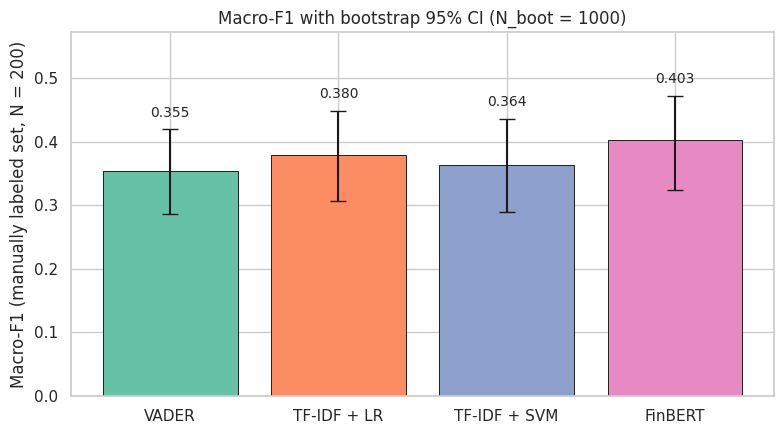

Saved: /kaggle/working/figures/07_macro_f1_with_ci.png


In [17]:
# 5.3 — Bar chart of macro-F1 with CI error bars
# Defensive: if ci_df doesn't exist (Section 5.2 skipped), rebuild it now

if "ci_df" not in dir():
    # Re-run bootstrap 95% CI for macro-F1 if not already done
    N_BOOT = 1000
    y_true = eval_df["y_true"].to_numpy()
    
    rng = np.random.default_rng(SEED)
    ci_rows = []
    boot_samples_by_model = {}
    
    for m in MODELS:
        y_pred = eval_df[LABEL_COLS[m]].to_numpy()
        boot_f1s = np.empty(N_BOOT, dtype=np.float64)
        n = len(y_true)
        for b in range(N_BOOT):
            idx = rng.integers(0, n, size=n)  # bootstrap resample with replacement
            boot_f1s[b] = f1_score(y_true[idx], y_pred[idx],
                                   average="macro", labels=LABELS, zero_division=0)
        boot_samples_by_model[m] = boot_f1s
        ci_rows.append({
            "model":        MODEL_DISPLAY[m],
            "macro_f1":     metrics_df.loc[MODEL_DISPLAY[m], "macro_f1"],
            "ci_lower_95":  np.percentile(boot_f1s, 2.5),
            "ci_upper_95":  np.percentile(boot_f1s, 97.5),
            "boot_std":     boot_f1s.std(),
        })
    
    ci_df = pd.DataFrame(ci_rows).set_index("model")
    print(f"Bootstrap 95% CIs computed (ci_df was missing)\n")

fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(ci_df))
means  = ci_df["macro_f1"].values
lowers = means - ci_df["ci_lower_95"].values
uppers = ci_df["ci_upper_95"].values - means

colors = sns.color_palette("Set2", n_colors=len(ci_df))
ax.bar(x, means, yerr=[lowers, uppers], capsize=6, color=colors, edgecolor="black", linewidth=0.6)

for i, (m, row) in enumerate(ci_df.iterrows()):
    ax.text(i, row["macro_f1"] + uppers[i] + 0.015,
            f"{row['macro_f1']:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(ci_df.index)
ax.set_ylabel(f"Macro-F1 (manually labeled set, N = {len(eval_df)})")
ax.set_ylim(0, min(1.0, (ci_df["ci_upper_95"].max() + 0.1)))
ax.set_title(f"Macro-F1 with bootstrap 95% CI (N_boot = {N_BOOT})")
plt.tight_layout()

out = FIGURES_DIR / "07_macro_f1_with_ci.png"
plt.savefig(out); plt.show()
print(f"Saved: {out}")

## Section 6 — Confusion Matrices and Pairwise Significance

Confusion matrices tell me *how* each model fails. A model that confuses positive with neutral is qualitatively different from one that confuses positive with negative — the first is cautious, the second is broken. I normalize by true class so the rows sum to 1, making recall visually readable as the diagonal.

For statistical significance between model pairs, I use McNemar's test on the manually-labeled set. The test asks: of the documents where the two models disagree, does one model systematically get more of them right? If the McNemar p-value is above 0.05, the observed macro-F1 gap might be driven by a handful of cases and should not be claimed as a real difference.


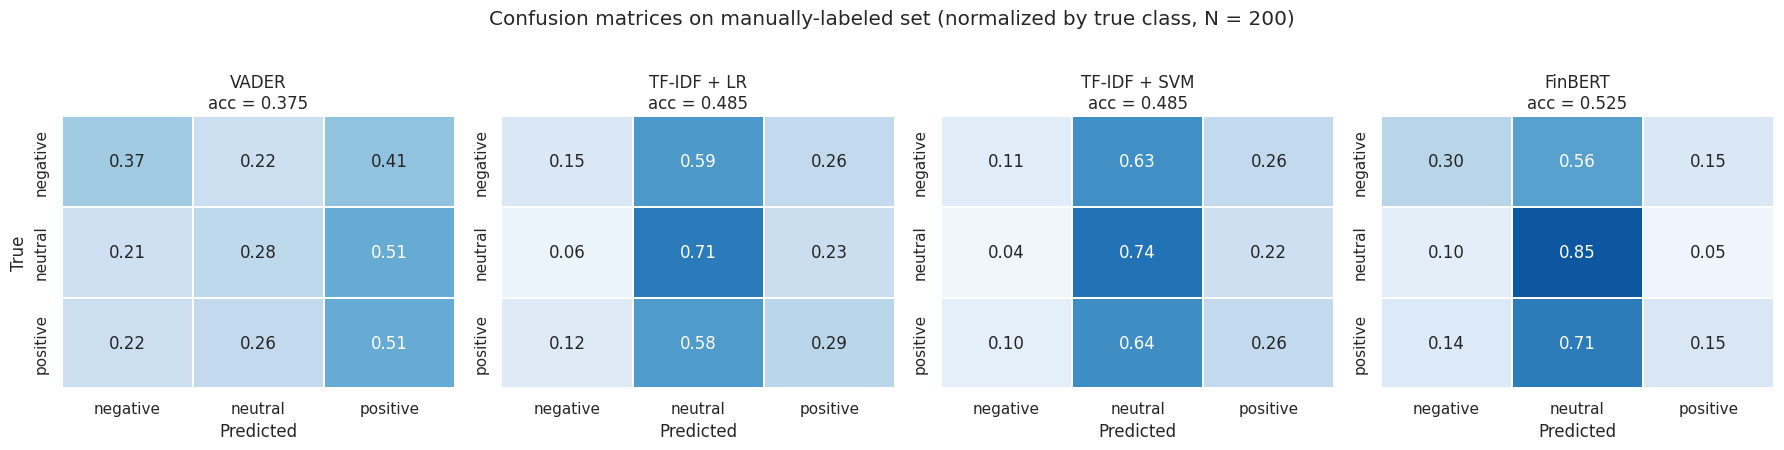

Saved: /kaggle/working/figures/07_confusion_matrices.png


In [18]:
# 6.1 — 4-panel confusion matrices

fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
for ax, m in zip(axes, MODELS):
    cm = confusion_matrix(eval_df["y_true"], eval_df[LABEL_COLS[m]], labels=LABELS, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax,
                linewidths=0.3)
    acc = accuracy_score(eval_df["y_true"], eval_df[LABEL_COLS[m]])
    ax.set_title(f"{MODEL_DISPLAY[m]}\nacc = {acc:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True" if m == MODELS[0] else "")

plt.suptitle(f"Confusion matrices on manually-labeled set (normalized by true class, N = {len(eval_df)})", y=1.02)
plt.tight_layout()

out = FIGURES_DIR / "07_confusion_matrices.png"
plt.savefig(out); plt.show()
print(f"Saved: {out}")


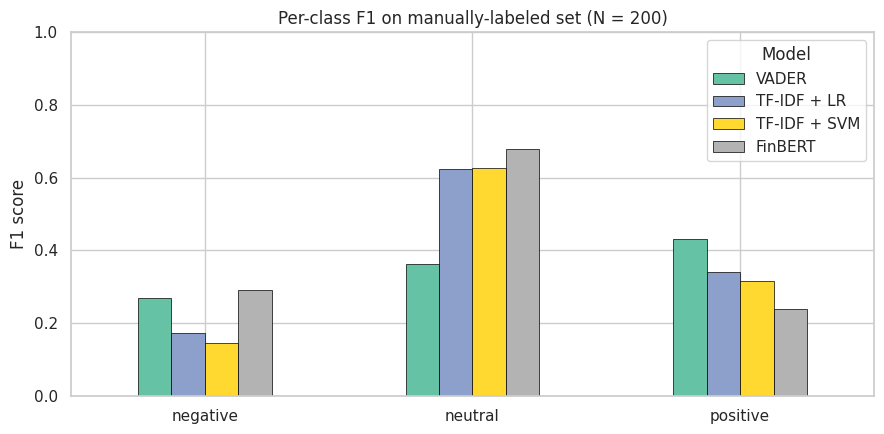

Saved: /kaggle/working/figures/07_per_class_f1.png


In [19]:
# 6.2 — Per-class F1 grouped bar chart

f1_per_class = pd.DataFrame({
    MODEL_DISPLAY[m]: [metrics_df.loc[MODEL_DISPLAY[m], f"F1_{lbl}"] for lbl in LABELS]
    for m in MODELS
}, index=LABELS)

fig, ax = plt.subplots(figsize=(9, 4.5))
f1_per_class.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black", linewidth=0.5)
ax.set_ylabel("F1 score")
ax.set_xlabel("")
ax.set_title(f"Per-class F1 on manually-labeled set (N = {len(eval_df)})")
ax.set_ylim(0, 1.0)
ax.legend(title="Model", loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()

out = FIGURES_DIR / "07_per_class_f1.png"
plt.savefig(out); plt.show()
print(f"Saved: {out}")


In [20]:
# 6.3 — Pairwise McNemar's test

# For each pair of models, build a 2x2 contingency table of correct/incorrect
# predictions on the labeled set, then run McNemar's test.

def mcnemar_table(y_true, y_pred_a, y_pred_b):
    a_correct = (y_pred_a == y_true)
    b_correct = (y_pred_b == y_true)
    return np.array([
        [( a_correct &  b_correct).sum(), ( a_correct & ~b_correct).sum()],
        [(~a_correct &  b_correct).sum(), (~a_correct & ~b_correct).sum()],
    ])

mc_rows = []
for m1, m2 in combinations(MODELS, 2):
    table = mcnemar_table(
        eval_df["y_true"].to_numpy(),
        eval_df[LABEL_COLS[m1]].to_numpy(),
        eval_df[LABEL_COLS[m2]].to_numpy(),
    )
    # exact binomial when discordant count is small, else chi-square with continuity
    n_discordant = table[0, 1] + table[1, 0]
    res = mcnemar(table, exact=(n_discordant < 25), correction=True)
    mc_rows.append({
        "pair":           f"{MODEL_DISPLAY[m1]} vs {MODEL_DISPLAY[m2]}",
        f"{MODEL_DISPLAY[m1]}_only_correct": int(table[0, 1]),
        f"{MODEL_DISPLAY[m2]}_only_correct": int(table[1, 0]),
        "statistic":      float(res.statistic),
        "p_value":        float(res.pvalue),
        "significant_05": bool(res.pvalue < 0.05),
    })

mc_df = pd.DataFrame(mc_rows)
print(f"McNemar's test on manually-labeled set (N = {len(eval_df)}):\n")
# Simpler display columns
display_cols = ["pair", "statistic", "p_value", "significant_05"]
print(mc_df[display_cols].round(4).to_string(index=False))


McNemar's test on manually-labeled set (N = 200):

                       pair  statistic  p_value  significant_05
       VADER vs TF-IDF + LR     5.2500   0.0219            True
      VADER vs TF-IDF + SVM     4.9000   0.0269            True
           VADER vs FinBERT     8.7604   0.0031            True
TF-IDF + LR vs TF-IDF + SVM     3.0000   1.0000           False
     TF-IDF + LR vs FinBERT     0.9074   0.3408           False
    TF-IDF + SVM vs FinBERT     0.9800   0.3222           False


## Section 7 — Macro-F1 per Model × Source

Aggregate macro-F1 can hide a lot. Maybe FinBERT wins overall because it dominates on news (which is half the corpus) while losing to VADER on twitter_musk. The thesis story is stronger if I can say exactly where each model's advantage comes from — and where it isn't there at all.

Per-source N is only 50, so these numbers are noisier than the aggregate. I don't compute bootstrap CIs for each cell (the plot would become unreadable), but the qualitative ranking per source is what matters here.


Rebuilt eval_df from internal sample + labels. Cols restored: ['source']
Macro-F1 per (model × source):

                  n  VADER  TF-IDF + LR  TF-IDF + SVM  FinBERT
source                                                        
news             50  0.420        0.360         0.296    0.550
reddit            3  0.333        0.667         0.667    0.333
twitter_general  20  0.306        0.292         0.284    0.178
twitter_musk     50  0.197        0.307         0.290    0.350


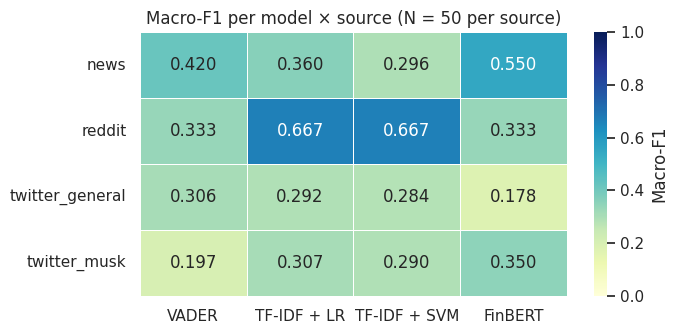

Saved: /kaggle/working/figures/07_macro_f1_per_source.png


In [21]:
# 7.1 — Per-source macro-F1 table and heatmap
# Defensive: ensure eval_df has full metadata (doc_id, source, y_true, all predictions)

required_cols = ["doc_id", "source", "y_true"] + list(LABEL_COLS.values())
missing_cols = [c for c in required_cols if c not in eval_df.columns]

if missing_cols:
    # Rebuild eval_df from scratch by re-joining all pieces
    # Load the internal sample (has doc_id, source, text, and all 4 model predictions)
    sample = pd.read_parquet(DATA_DIR / "_internal_sample_with_preds.parquet")
    
    # Load the filled labels (has doc_id, y_true)
    labels_df = pd.read_csv(LABELS_FILLED_PATH, encoding="utf-8", keep_default_na=False)
    labels_df["label"] = labels_df["label"].astype(str).str.strip().str.lower()
    labels_df = labels_df.rename(columns={"label": "y_true"})
    
    # Merge to restore everything
    eval_df = sample.merge(labels_df[["doc_id", "y_true"]], on="doc_id", how="inner", validate="one_to_one")
    
    missing_after = [c for c in required_cols if c not in eval_df.columns]
    assert not missing_after, f"Still missing columns after rebuild: {missing_after}"
    print(f"Rebuilt eval_df from internal sample + labels. Cols restored: {missing_cols}")

per_source_rows = []
for src in SOURCES:
    sub = eval_df[eval_df["source"] == src]
    if len(sub) == 0:
        print(f"Warning: no samples from source '{src}'")
        continue
    row = {"source": src, "n": len(sub)}
    for m in MODELS:
        row[MODEL_DISPLAY[m]] = f1_score(
            sub["y_true"], sub[LABEL_COLS[m]], average="macro", labels=LABELS, zero_division=0,
        )
    per_source_rows.append(row)

per_source_df = pd.DataFrame(per_source_rows).set_index("source")
print("Macro-F1 per (model × source):\n")
print(per_source_df.round(3).to_string())

# Heatmap
plot_df = per_source_df.drop(columns=["n"]).astype(float)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(plot_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1,
            cbar_kws={"label": "Macro-F1"}, linewidths=0.5, ax=ax)
ax.set_title(f"Macro-F1 per model × source (N = {SAMPLE_PER_SOURCE} per source)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
out = FIGURES_DIR / "07_macro_f1_per_source.png"
plt.savefig(out); plt.show()
print(f"Saved: {out}")

## Section 8 — Headline vs Full-Text FinBERT (News Only)

Notebook 06 ran FinBERT twice on news articles: once on the first 512 tokens of the full text, and once on the headline alone. The headline track was motivated by the token-length analysis: many news articles exceeded FinBERT's 512-token limit, and truncating the body could cause the model to miss the actual sentiment-carrying content.

On the labeled subset of news rows (50 docs), I can finally answer: does the headline track outperform the full-text track, or does it sacrifice too much context?


In [22]:
# 8.1 — Compare finbert_label (full text) vs finbert_label_headline on labeled news

news_eval = eval_df[eval_df["source"] == "news"].copy()

if "finbert_label_headline" not in news_eval.columns:
    print("finbert_label_headline column not present — skipping headline comparison.")
    headline_results = None
else:
    n_with_headline = news_eval["finbert_label_headline"].notna().sum()
    print(f"News rows in labeled set: {len(news_eval)}")
    print(f"  with headline prediction: {n_with_headline}")

    if n_with_headline >= 20:
        with_hl = news_eval[news_eval["finbert_label_headline"].notna()].copy()
        f1_full = f1_score(with_hl["y_true"], with_hl["finbert_label"],
                           average="macro", labels=LABELS, zero_division=0)
        f1_head = f1_score(with_hl["y_true"], with_hl["finbert_label_headline"],
                           average="macro", labels=LABELS, zero_division=0)
        agree = (with_hl["finbert_label"] == with_hl["finbert_label_headline"]).mean()

        # McNemar between the two FinBERT variants
        table = mcnemar_table(
            with_hl["y_true"].to_numpy(),
            with_hl["finbert_label"].to_numpy(),
            with_hl["finbert_label_headline"].to_numpy(),
        )
        res = mcnemar(table, exact=(table[0, 1] + table[1, 0] < 25), correction=True)

        headline_results = {
            "n":                  int(len(with_hl)),
            "macro_f1_fulltext":  float(f1_full),
            "macro_f1_headline":  float(f1_head),
            "agreement_pct":      float(agree * 100),
            "mcnemar_statistic":  float(res.statistic),
            "mcnemar_p_value":    float(res.pvalue),
        }
        print(f"\nMacro-F1 FinBERT full-text: {f1_full:.3f}")
        print(f"Macro-F1 FinBERT headline:  {f1_head:.3f}")
        print(f"Agreement between tracks:   {agree * 100:.1f}%")
        print(f"McNemar p-value:            {res.pvalue:.4f}  ({'significant' if res.pvalue < 0.05 else 'not significant'} at α=0.05)")
    else:
        print(f"Only {n_with_headline} news rows with headline predictions — skipping (need ≥20).")
        headline_results = None


News rows in labeled set: 50
  with headline prediction: 50

Macro-F1 FinBERT full-text: 0.550
Macro-F1 FinBERT headline:  0.511
Agreement between tracks:   86.0%
McNemar p-value:            1.0000  (not significant at α=0.05)


## Section 9 — Qualitative Error Analysis (FinBERT)

A handful of real errors, read carefully, often reveals more about a model than any aggregate metric. I pull a random sample of cases where FinBERT disagreed with my manual label and write a short thesis note about the error categories I observe. The typical categories in financial-sentiment work are: sarcasm and irony (especially on Reddit), domain-specific phrasing that FinBERT was undertrained on, truncation losing the sentiment-bearing passage, and genuinely ambiguous texts where I'd have to flip a coin myself.


In [23]:
# 9.1 — Sample 15 FinBERT errors from the labeled set
# Defensive: ensure eval_df has the text column

if "text" not in eval_df.columns:
    sample = pd.read_parquet(DATA_DIR / "_internal_sample_with_preds.parquet")
    sample_text = sample[["doc_id", "text"]].copy()
    eval_df = eval_df.merge(sample_text, on="doc_id", how="left", validate="one_to_one")
    print(f"Restored 'text' column from internal sample snapshot")

finbert_errors = eval_df[eval_df["y_true"] != eval_df["finbert_label"]].copy()
print(f"FinBERT errors on labeled set: {len(finbert_errors)} / {len(eval_df)} "
      f"({len(finbert_errors) / len(eval_df) * 100:.1f}%)")
print("Errors by source:")
print(finbert_errors["source"].value_counts().reindex(SOURCES).fillna(0).astype(int).to_string())

n_show = min(15, len(finbert_errors))
error_sample = finbert_errors.sample(n=n_show, random_state=SEED) if n_show > 0 else finbert_errors

print(f"\n{'=' * 80}")
print(f"Random sample of {n_show} errors for qualitative inspection:")
print(f"{'=' * 80}\n")

for i, (_, row) in enumerate(error_sample.iterrows(), 1):
    # Safely handle text (may be NaN or missing)
    text = row.get("text", "")
    if pd.isna(text):
        text = "(text not available)"
    else:
        text = str(text)[:300] + ("..." if len(text) > 300 else "")
    
    conf = row.get("finbert_confidence", np.nan)
    conf_str = f"{conf:.2f}" if not pd.isna(conf) else "N/A"
    
    print(f"[{i}] source={row['source']:<16} true={row['y_true']:<9} pred={row['finbert_label']:<9} conf={conf_str}")
    print(f"    TEXT: {text}")
    print()

FinBERT errors on labeled set: 51 / 123 (41.5%)
Errors by source:
source
news               17
reddit              1
twitter_general    15
twitter_musk       18

Random sample of 15 errors for qualitative inspection:

[1] source=twitter_musk     true=neutral   pred=negative  conf=0.79
    TEXT: @SawyerMerritt People still don’t understand the implications of FSD

[2] source=twitter_musk     true=negative  pred=neutral   conf=0.93
    TEXT: @ajtourville @thirdrowtesla Certainly no problem for a 144 trillion operations per second computer to make ~15 steering/acceleration/braking maneuvers per second. That’s a trillion calculations between each output command.

[3] source=twitter_musk     true=positive  pred=neutral   conf=0.91
    TEXT: @Teslarati @ResidentSponge It is an electronics/mechanical/software engineering problem for the Neuralink device that is similar in complexity level to smart watches (which are not easy!), plus the surgical robot, which is comparable to state-of-the art 

## Section 10 — Final Unified Output

I save two artifacts. The parquet joins all four models' labels, probabilities, and confidence scores for every one of the ~85K docs, with FinBERT's label designated as `primary_label` — Step 4 will aggregate this into daily sentiment indices. The JSON file captures every metric, CI, and p-value from this notebook so the thesis numbers are all reproducible from a single file.


In [24]:
# 10.1 — Save layer2_sentiment.parquet (the full 85K with all four models joined)

final_df = merged.copy()

# Designate FinBERT as the project's primary sentiment label.
# Step 4 will aggregate on primary_label by default, but all four model labels
# are preserved in the file so ablations and source-specific overrides stay possible.
final_df["primary_label"]      = final_df["finbert_label"]
final_df["primary_confidence"] = final_df.get("finbert_confidence", np.nan)

OUTPUT_PATH = DATA_DIR / "layer2_sentiment.parquet"
final_df.to_parquet(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Rows:  {len(final_df):,}")
print(f"Cols:  {len(final_df.columns)}")
print(f"\nPrimary label distribution (from FinBERT):")
print(final_df["primary_label"].value_counts(normalize=True).reindex(LABELS).round(3).to_string())


Saved: /kaggle/working/data/layer2_sentiment.parquet
Rows:  85,647
Cols:  39

Primary label distribution (from FinBERT):
primary_label
negative    0.146
neutral     0.762
positive    0.092


In [25]:
# 10.2 — Save comparison_results.json

def to_jsonable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, pd.DataFrame):
        return obj.reset_index().to_dict(orient="records")
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    return obj

results = {
    "run_timestamp":     RUN_TS,
    "seed":              SEED,
    "library_versions":  VERSIONS,
    "inputs": {
        "baselines_path":      str(BASELINES_PATH),
        "finbert_path":        str(FINBERT_PATH),
        "labels_filled_path":  str(LABELS_FILLED_PATH),
    },
    "corpus": {
        "n_documents":         int(len(merged)),
        "per_source_counts":   merged["source"].value_counts().reindex(SOURCES).to_dict(),
    },
    "inter_model_agreement_full_corpus": {
        "kappa_matrix":        kappa_matrix.astype(float).to_dict(),
        "kappa_by_source":     pair_pivot.astype(float).to_dict(),
    },
    "labeled_set": {
        "n":                   int(len(eval_df)),
        "per_source_counts":   eval_df["source"].value_counts().reindex(SOURCES).to_dict(),
        "class_distribution":  eval_df["y_true"].value_counts().reindex(LABELS).to_dict(),
        "inter_annotator_kappa": kappa_inter,
    },
    "per_model_metrics":       metrics_df.reset_index().to_dict(orient="records"),
    "bootstrap_95ci_macro_f1": ci_df.reset_index().to_dict(orient="records"),
    "mcnemar_pairwise":        mc_df.to_dict(orient="records"),
    "per_source_macro_f1":     per_source_df.reset_index().to_dict(orient="records"),
    "headline_vs_fulltext":    headline_results,
    "output_dataset":          str(OUTPUT_PATH),
    "figures": [
        str(FIGURES_DIR / f) for f in [
            "07_kappa_heatmap.png",
            "07_kappa_by_source.png",
            "07_macro_f1_with_ci.png",
            "07_confusion_matrices.png",
            "07_per_class_f1.png",
            "07_macro_f1_per_source.png",
        ]
    ],
}

results = to_jsonable(results)
RESULTS_PATH = RESULTS_DIR / "comparison_results.json"
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2, default=str)

print(f"Saved: {RESULTS_PATH}")


Saved: /kaggle/working/results/comparison_results.json


## Section 11 — Summary, Limitations, Bridge to Step 4

### What was produced

- A unified 4-model sentiment dataset on all ~85K TSLA documents (`layer2_sentiment.parquet`), with FinBERT designated as `primary_label` for Step 4.
- Pairwise Cohen's kappa on the full corpus, broken down by source.
- Per-model accuracy / macro-F1 / weighted-F1 / per-class F1 on 200 manually labeled documents.
- Bootstrap 95% CIs for every model's macro-F1.
- McNemar's test for pairwise statistical significance between all six model pairs.
- Macro-F1 per model × source, and a FinBERT headline-vs-full-text comparison on labeled news rows.
- Six thesis-quality figures and a consolidated `comparison_results.json`.

### Honest limitations to document in the thesis

1. **The labeled set is 200 documents.** This is a defensible size for macro-F1 with CIs, but small enough that per-source per-class cells (N ≈ 15 per cell) are noisy. Conclusions at the cell level should be stated as trends, not proofs.
2. **FinBERT was fine-tuned on Financial PhraseBank**, which is news-register prose. Its out-of-domain performance on Reddit and Twitter is a real question, and the per-source breakdown in Section 7 is the evidence the thesis uses to address it.
4. **Bootstrap CIs assume the labeled sample is representative of the 85K corpus.** Because the sample is stratified by source (not proportional), the aggregate CIs slightly under-represent news — this is a conscious tradeoff for statistical power on the minority sources.

### Next steps — Step 4: Feature Engineering

- **Notebook 08** — `08_feature_engineering.ipynb`: aggregate `primary_label` into daily sentiment indices per source, joined with `yfinance` OHLCV for TSLA (2020–2023). Build daily features: sentiment volume, polarity mean, polarity std, Musk-only sub-index, news vs social cross-signal, lagged features, and price technicals.
- **Notebook 09+** — Step 5 modeling: Random Forest, XGBoost, LSTM with Bahdanau Attention, Temporal Transformer. Targets: next-day return direction and trading-signal labels (BUY/SELL/HOLD). Metrics: accuracy, directional accuracy, Sharpe ratio of the strategy backtest.
